In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# Bước 1: Load dữ liệu từ bước trước
# ==========================================
df = pd.read_csv('vix_features_1D.csv')
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

# ==========================================
# Bước 2: Bổ sung chỉ báo (Complex Indicators)
# ==========================================
# 1. Bollinger Bands (chu kỳ 20)
df['SMA_20'] = df['close'].rolling(window=20).mean()
df['BB_std'] = df['close'].rolling(window=20).std()
df['BB_upper'] = df['SMA_20'] + (df['BB_std'] * 2)
df['BB_lower'] = df['SMA_20'] - (df['BB_std'] * 2)

# 2. MACD (chu kỳ 12, 26, 9)
df['EMA_12'] = df['close'].ewm(span=12, adjust=False).mean()
df['EMA_26'] = df['close'].ewm(span=26, adjust=False).mean()
df['MACD'] = df['EMA_12'] - df['EMA_26']
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

# Xóa các dòng có giá trị NaN do tính toán rolling/lag ở những ngày đầu tiên
df = df.dropna().reset_index(drop=True)

# ==========================================
# Bước 3: Định nghĩa Features & Target
# ==========================================
# Lấy các cột làm đầu vào (có thể bỏ cột 'time' và các cột trung gian không cần thiết)
features = ['open', 'high', 'low', 'close', 'volume', 'SMA_10', 'RSI_14', 
            'lag_1', 'lag_5', 'SMA_20', 'BB_upper', 'BB_lower', 'MACD', 'MACD_Signal']

data_features = df[features].values
# Giả sử bài toán là dự đoán giá đóng cửa (close) của ngày tiếp theo
data_target = df['close'].values 

# ==========================================
# Bước 4: Chuẩn hóa dữ liệu (Scaling)
# ==========================================
# Sử dụng MinMaxScaler để đưa dữ liệu về dải [0, 1] giúp model Deep Learning học nhanh hơn
scaler_features = MinMaxScaler(feature_range=(0, 1))
scaler_target = MinMaxScaler(feature_range=(0, 1))

scaled_features = scaler_features.fit_transform(data_features)
scaled_target = scaler_target.fit_transform(data_target.reshape(-1, 1))

# ==========================================
# Bước 5: Tạo chuỗi thời gian (Sliding Window)
# ==========================================
def create_sliding_window(features, target, window_size):
    X, y = [], []
    for i in range(len(features) - window_size):
        # Lấy một cửa sổ dữ liệu làm input
        X.append(features[i:(i + window_size)])
        # Lấy giá trị của bước tiếp theo ngay sau cửa sổ làm label
        y.append(target[i + window_size])
    return np.array(X), np.array(y)

WINDOW_SIZE = 60 # Dùng dữ liệu 60 ngày quá khứ để dự đoán ngày kế tiếp
X, y = create_sliding_window(scaled_features, scaled_target, WINDOW_SIZE)

# ==========================================
# Bước 6: Train / Test Split
# ==========================================
# LƯU Ý: Với Time-Series, ta chia cắt theo thời gian tuần tự (không dùng train_test_split có xáo trộn random)
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Shape của X_train : {X_train.shape}")
print(f"Shape của y_train : {y_train.shape}")
print(f"Shape của X_test  : {X_test.shape}")
print(f"Shape của y_test  : {y_test.shape}")

# ==========================================
# Bước 7: Lưu file Output ra định dạng .npy
# ==========================================
# Gói các ma trận vào một dictionary và lưu thành file .npy duy nhất
dataset_dict = {
    'X_train': X_train,
    'y_train': y_train,
    'X_test': X_test,
    'y_test': y_test
}

# Lưu file (cần allow_pickle=True vì ta đang lưu Dictionary object)
np.save('dataset_ready_for_DL.npy', dataset_dict, allow_pickle=True)

# Nếu muốn lưu đúng chuẩn của Numpy cho nhiều mảng (khuyên dùng cho dự án sau):
# np.savez('dataset_ready_for_DL.npz', X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)

print("\nHoàn tất! Đã lưu tập dữ liệu vào file: dataset_ready_for_DL.npy")

Shape của X_train : (1919, 60, 14)
Shape của y_train : (1919, 1)
Shape của X_test  : (480, 60, 14)
Shape của y_test  : (480, 1)

Hoàn tất! Đã lưu tập dữ liệu vào file: dataset_ready_for_DL.npy


In [2]:
import numpy as np

# 1. Tải toàn bộ dữ liệu từ file
# Tham số allow_pickle=True là bắt buộc vì file chứa cấu trúc dictionary
dataset = np.load('dataset_ready_for_DL.npy', allow_pickle=True).item()

# 2. Xem tất cả các thành phần (các mảng) đang được lưu trong file
print("Các thành phần có trong file (Keys):", dataset.keys())

# 3. Truy xuất từng mảng dữ liệu cụ thể và gán vào các biến
# Khối lệnh try-except này giúp lấy dữ liệu an toàn phòng trường hợp thiếu key
try:
    X_train = dataset['X_train']
    print(f"\nKích thước của X_train: {X_train.shape}")
    
    # Lấy các phần dữ liệu khác nếu có
    if 'y_train' in dataset:
        y_train = dataset['y_train']
        print(f"Kích thước của y_train: {y_train.shape}")
        
    if 'X_test' in dataset:
        X_test = dataset['X_test']
        print(f"Kích thước của X_test: {X_test.shape}")
        
    if 'y_test' in dataset:
        y_test = dataset['y_test']
        print(f"Kích thước của y_test: {y_test.shape}")

except KeyError as e:
    print(f"Không tìm thấy key: {e}")

# 4. Hiển thị thử một vài dòng dữ liệu của X_train
print("\nMột vài mẫu dữ liệu đầu tiên trong X_train:")
print(X_train[:2])

Các thành phần có trong file (Keys): dict_keys(['X_train', 'y_train', 'X_test', 'y_test'])

Kích thước của X_train: (1919, 60, 14)
Kích thước của y_train: (1919, 1)
Kích thước của X_test: (480, 60, 14)
Kích thước của y_test: (480, 1)

Một vài mẫu dữ liệu đầu tiên trong X_train:
[[[0.00817934 0.00750751 0.00866337 ... 0.00773421 0.4017987  0.3879503 ]
  [0.00848228 0.00690691 0.00835396 ... 0.00738683 0.40159902 0.3876491 ]
  [0.00727052 0.00660661 0.00835396 ... 0.00711461 0.40150124 0.38738602]
  ...
  [0.00484702 0.0036036  0.00587871 ... 0.00448084 0.40760069 0.39373966]
  [0.00484702 0.0033033  0.0052599  ... 0.00448084 0.4074697  0.39360815]
  [0.00424114 0.0036036  0.0052599  ... 0.00448084 0.40735884 0.39347788]]

 [[0.00848228 0.00690691 0.00835396 ... 0.00738683 0.40159902 0.3876491 ]
  [0.00727052 0.00660661 0.00835396 ... 0.00711461 0.40150124 0.38738602]
  [0.00817934 0.00750751 0.00866337 ... 0.00707525 0.40173646 0.38722875]
  ...
  [0.00484702 0.0033033  0.0052599  ... 0

In [3]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu
df = pd.read_csv("vix_features_1D.csv")

# 2. Xử lý thời gian và đặt làm Index
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)
df.sort_index(inplace=True) # Đảm bảo dữ liệu được sắp xếp theo thời gian

# 3. Tạo biến mục tiêu (Target) - Dự đoán giá close của ngày tiếp theo
df['target_close'] = df['close'].shift(-1)

# Loại bỏ dòng cuối cùng bị NaN do hàm shift
df.dropna(inplace=True)


In [4]:
# 4. Tách Features (X) và Target (y)
X = df.drop(columns=['target_close'])
y = df['target_close']

# 5. Chia tập Train / Test theo thời gian (ví dụ: 80% train, 20% test)
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Số lượng tập Train: {len(X_train)}")
print(f"Số lượng tập Test: {len(X_test)}")

# 6. Chuẩn hóa dữ liệu (Scaling)
scaler = MinMaxScaler()
# Chỉ fit scaler trên tập train để tránh data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# (Tùy chọn) Chuyển lại thành DataFrame nếu bạn muốn dùng Pandas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

Số lượng tập Train: 1981
Số lượng tập Test: 496


1. ĐANG TẢI DỮ LIỆU...
Train shape: (1919, 60, 14), Test shape: (480, 60, 14)

2. ĐANG TRÍCH XUẤT ĐẶC TRƯNG THỐNG KÊ (Feature Engineering)...
Shape dữ liệu mới (Train): (1919, 84), (Test): (480, 84)

3. HUẤN LUYỆN CÁC MÔ HÌNH MACHINE LEARNING...
------------------------------------------------------------
Linear Regression | MAE: 0.0130 | MSE: 0.0004 | RMSE: 0.0190 | R2: 0.9924 | MAPE: 2.79%
Random Forest   | MAE: 0.1789 | MSE: 0.0684 | RMSE: 0.2615 | R2: -0.4309 | MAPE: 36.74%
XGBoost (Basic) | MAE: 0.1410 | MSE: 0.0506 | RMSE: 0.2250 | R2: -0.0592 | MAPE: 38.03%
------------------------------------------------------------
   Đang tối ưu XGBoost (RandomizedSearchCV)...
XGBoost (Eng+Tuned) | MAE: 0.1859 | MSE: 0.0730 | RMSE: 0.2701 | R2: -0.5268 | MAPE: 35.59%

4. HUẤN LUYỆN MÔ HÌNH LSTM...
------------------------------------------------------------
LSTM            | MAE: 0.0896 | MSE: 0.0229 | RMSE: 0.1513 | R2: 0.5210 | MAPE: 13.70%

5. TRỰC QUAN HÓA KẾT QUẢ...
  -> Đã lưu biểu đồ s

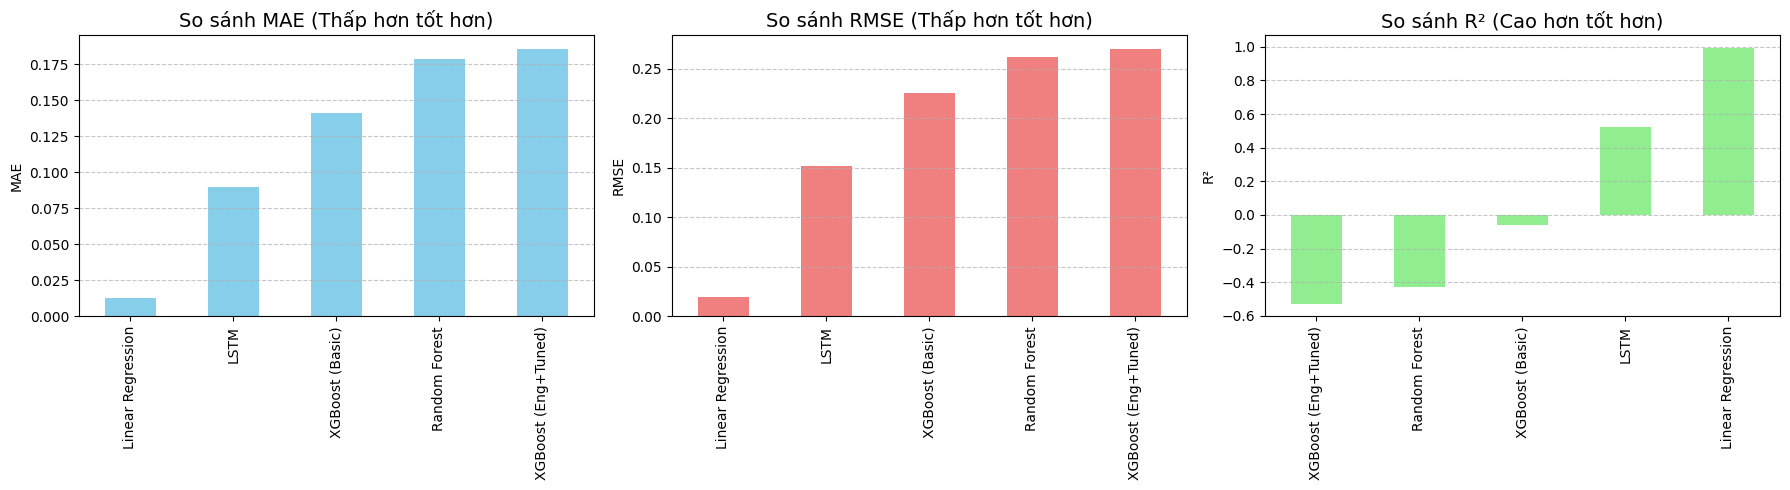

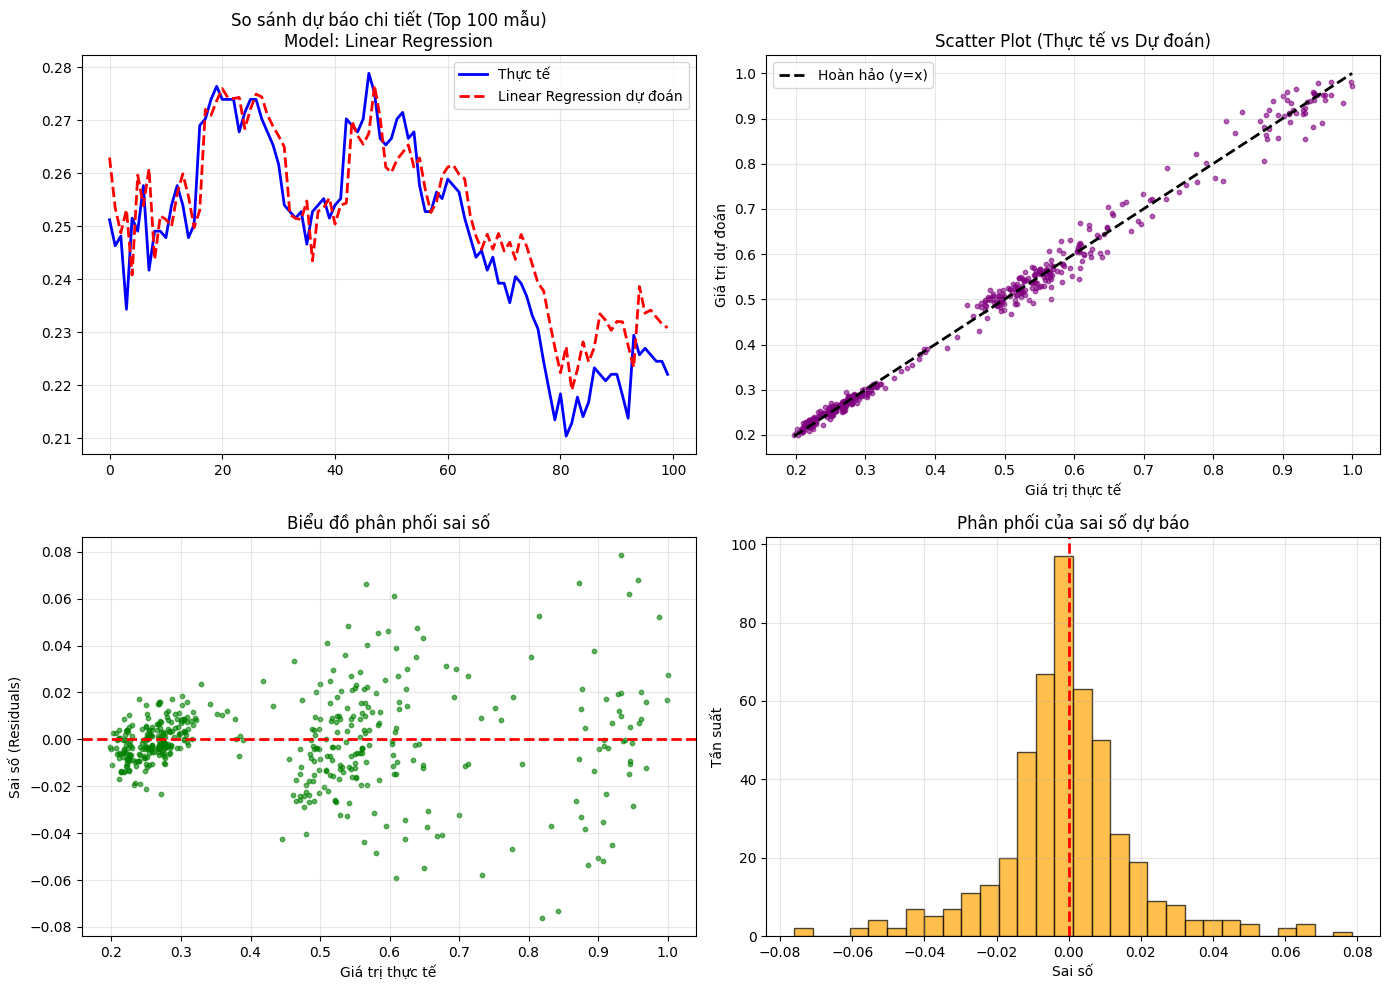

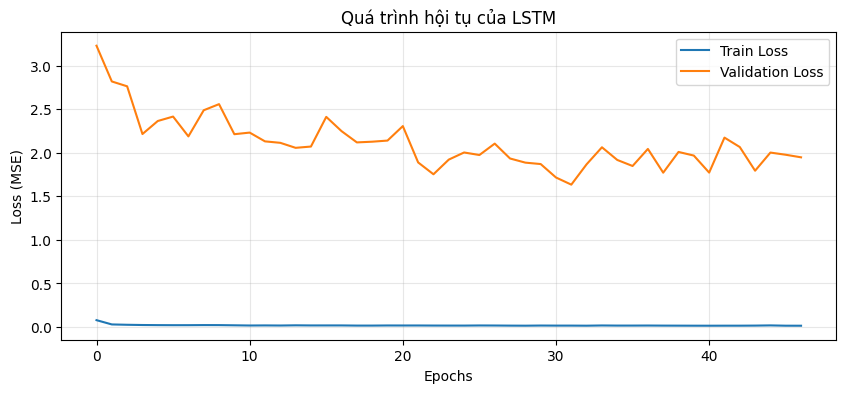

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten, Attention, Permute, Reshape
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# ------------------- 1. TẢI & CHUẨN BỊ DỮ LIỆU -------------------
print("="*60)
print("1. ĐANG TẢI DỮ LIỆU...")
data = np.load('dataset_ready_for_DL.npy', allow_pickle=True).item()
X_train, y_train = data['X_train'], data['y_train']
X_test, y_test = data['X_test'], data['y_test']
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# ------------------- 2. FEATURE ENGINEERING THÔNG MINH (Trích xuất thống kê) -------------------
def extract_statistical_features(X):
    """
    X có shape (samples, timesteps=60, features=14)
    Trích xuất: Mean, Std, Max, Min, Slope (hồi quy tuyến tính), Kurtosis
    Kết quả: (samples, 14 * 6 = 84 đặc trưng)
    """
    samples = X.shape[0]
    n_features = X.shape[2]
    stat_list = []
    
    for i in range(samples):
        sample_stats = []
        for f in range(n_features):
            ts = X[i, :, f]
            # 1. Trung bình
            sample_stats.append(np.mean(ts))
            # 2. Độ lệch chuẩn
            sample_stats.append(np.std(ts))
            # 3. Giá trị lớn nhất
            sample_stats.append(np.max(ts))
            # 4. Giá trị nhỏ nhất
            sample_stats.append(np.min(ts))
            # 5. Độ dốc (Slope) - hồi quy tuyến tính đơn giản
            x_axis = np.arange(len(ts))
            slope = np.polyfit(x_axis, ts, 1)[0]
            sample_stats.append(slope)
            # 6. Kurtosis (độ nhọn)
            if np.std(ts) != 0:
                kurt = np.mean((ts - np.mean(ts))**4) / (np.std(ts)**4) - 3
            else:
                kurt = 0
            sample_stats.append(kurt)
        stat_list.append(sample_stats)
    
    return np.array(stat_list)

print("\n2. ĐANG TRÍCH XUẤT ĐẶC TRƯNG THỐNG KÊ (Feature Engineering)...")
X_train_stats = extract_statistical_features(X_train)
X_test_stats = extract_statistical_features(X_test)
print(f"Shape dữ liệu mới (Train): {X_train_stats.shape}, (Test): {X_test_stats.shape}")

# ------------------- 3. CHUẨN BỊ DỮ LIỆU CHO LSTM (Giữ nguyên chuỗi) -------------------
# LSTM cần dữ liệu được chuẩn hóa (Standardization) vì nhạy cảm với thang đo
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Reshape để fit scaler: (samples, 60*14) -> fit -> reshape lại
X_train_flat_for_scaler = X_train.reshape(X_train.shape[0], -1)
X_test_flat_for_scaler = X_test.reshape(X_test.shape[0], -1)

X_train_scaled = scaler_X.fit_transform(X_train_flat_for_scaler).reshape(X_train.shape)
X_test_scaled = scaler_X.transform(X_test_flat_for_scaler).reshape(X_test.shape)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

# ------------------- 4. HÀM ĐÁNH GIÁ TỔNG HỢP -------------------
def evaluate_model(name, y_true, y_pred):
    """Tính toán và in ra các chỉ số đánh giá"""
    # Nếu đầu vào là scaled, chuyển về gốc để tính MAPE cho dễ hiểu
    if name == "LSTM":
        y_true_orig = scaler_y.inverse_transform(y_true.reshape(-1, 1)).ravel()
        y_pred_orig = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()
    else:
        y_true_orig = y_true
        y_pred_orig = y_pred
    
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    mse = mean_squared_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true_orig, y_pred_orig)
    mape = np.mean(np.abs((y_true_orig - y_pred_orig) / y_true_orig)) * 100
    
    print(f"{name:15} | MAE: {mae:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f} | MAPE: {mape:.2f}%")
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

# ------------------- 5. HUẤN LUYỆN CÁC MÔ HÌNH ML -------------------
results = {}
predictions_dict = {}

# 5.1. Linear Regression
print("\n3. HUẤN LUYỆN CÁC MÔ HÌNH MACHINE LEARNING...")
print("-"*60)
lr = LinearRegression()
lr.fit(X_train_stats, y_train)
y_pred_lr = lr.predict(X_test_stats)
results['Linear Regression'] = evaluate_model('Linear Regression', y_test, y_pred_lr)
predictions_dict['Linear Regression'] = y_pred_lr

# 5.2. Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_stats, y_train)
y_pred_rf = rf.predict(X_test_stats)
results['Random Forest'] = evaluate_model('Random Forest', y_test, y_pred_rf)
predictions_dict['Random Forest'] = y_pred_rf

# 5.3. XGBoost Cơ bản (Flatten - như code cũ)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
xgb_basic = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, objective='reg:squarederror', random_state=42)
xgb_basic.fit(X_train_flat, y_train, eval_set=[(X_test_flat, y_test)], verbose=False)
y_pred_xgb_basic = xgb_basic.predict(X_test_flat)
results['XGBoost (Basic)'] = evaluate_model('XGBoost (Basic)', y_test, y_pred_xgb_basic)
predictions_dict['XGBoost (Basic)'] = y_pred_xgb_basic

# 5.4. XGBoost Đặc trưng (Feature Engineering + Tuning)
print("-"*60)
print("   Đang tối ưu XGBoost (RandomizedSearchCV)...")
param_dist = {
    'n_estimators': [300, 500, 700],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}
xgb_tuned = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
random_search = RandomizedSearchCV(xgb_tuned, param_dist, n_iter=15, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1, random_state=42, verbose=0)
random_search.fit(X_train_stats, y_train)
xgb_best = random_search.best_estimator_
y_pred_xgb_stats = xgb_best.predict(X_test_stats)
results['XGBoost (Eng+Tuned)'] = evaluate_model('XGBoost (Eng+Tuned)', y_test, y_pred_xgb_stats)
predictions_dict['XGBoost (Eng+Tuned)'] = y_pred_xgb_stats

# ------------------- 6. HUẤN LUYỆN DEEP LEARNING (LSTM) -------------------
print("\n4. HUẤN LUYỆN MÔ HÌNH LSTM...")
print("-"*60)

# Xây dựng mô hình LSTM
model_lstm = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model_lstm.fit(
    X_train_scaled, y_train_scaled,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_scaled, y_test_scaled),
    callbacks=[early_stop],
    verbose=0
)

y_pred_lstm_scaled = model_lstm.predict(X_test_scaled, verbose=0).ravel()
results['LSTM'] = evaluate_model('LSTM', y_test_scaled, y_pred_lstm_scaled)  # Lưu ý: truyền scaled, hàm sẽ tự inverse
predictions_dict['LSTM'] = y_pred_lstm_scaled

# ------------------- 7. TỔNG HỢP & TRỰC QUAN HÓA -------------------
print("\n" + "="*60)
print("5. TRỰC QUAN HÓA KẾT QUẢ...")

# Chuẩn bị dữ liệu cho biểu đồ so sánh
df_results = pd.DataFrame(results).T
df_results = df_results[['MAE', 'RMSE', 'R2']]  # Lấy 3 chỉ số chính

# 7.1. Biểu đồ cột so sánh các mô hình
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE
df_results.sort_values('MAE')[['MAE']].plot(kind='bar', ax=axes[0], legend=False, color='skyblue')
axes[0].set_title('So sánh MAE (Thấp hơn tốt hơn)', fontsize=14)
axes[0].set_ylabel('MAE')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# RMSE
df_results.sort_values('RMSE')[['RMSE']].plot(kind='bar', ax=axes[1], legend=False, color='lightcoral')
axes[1].set_title('So sánh RMSE (Thấp hơn tốt hơn)', fontsize=14)
axes[1].set_ylabel('RMSE')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# R2
df_results.sort_values('R2')[['R2']].plot(kind='bar', ax=axes[2], legend=False, color='lightgreen')
axes[2].set_title('So sánh R² (Cao hơn tốt hơn)', fontsize=14)
axes[2].set_ylabel('R²')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('model_comparison.png')
print("  -> Đã lưu biểu đồ so sánh: 'model_comparison.png'")

# 7.2. Biểu đồ chuyên sâu cho mô hình tốt nhất (dựa trên MAE thấp nhất)
best_model_name = df_results['MAE'].idxmin()
print(f"\n  Mô hình tốt nhất (theo MAE): {best_model_name}")
best_pred = predictions_dict[best_model_name]

# Nếu là LSTM, cần inverse transform để vẽ
if best_model_name == 'LSTM':
    best_pred_plot = scaler_y.inverse_transform(best_pred.reshape(-1, 1)).ravel()
    y_test_plot = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()
else:
    best_pred_plot = best_pred
    y_test_plot = y_test

fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))

# A. Actual vs Predicted (100 mẫu đầu)
axes2[0, 0].plot(y_test_plot[:100], label='Thực tế', color='blue', linewidth=2)
axes2[0, 0].plot(best_pred_plot[:100], label=f'{best_model_name} dự đoán', color='red', linestyle='--', linewidth=2)
axes2[0, 0].set_title(f'So sánh dự báo chi tiết (Top 100 mẫu)\nModel: {best_model_name}', fontsize=12)
axes2[0, 0].legend()
axes2[0, 0].grid(True, alpha=0.3)

# B. Scatter plot (Predicted vs Actual)
axes2[0, 1].scatter(y_test_plot, best_pred_plot, alpha=0.6, s=10, color='purple')
min_val = min(y_test_plot.min(), best_pred_plot.min())
max_val = max(y_test_plot.max(), best_pred_plot.max())
axes2[0, 1].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Hoàn hảo (y=x)')
axes2[0, 1].set_xlabel('Giá trị thực tế')
axes2[0, 1].set_ylabel('Giá trị dự đoán')
axes2[0, 1].set_title('Scatter Plot (Thực tế vs Dự đoán)')
axes2[0, 1].legend()
axes2[0, 1].grid(True, alpha=0.3)

# C. Residuals (Sai số)
residuals = y_test_plot - best_pred_plot
axes2[1, 0].scatter(y_test_plot, residuals, alpha=0.6, s=10, color='green')
axes2[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes2[1, 0].set_xlabel('Giá trị thực tế')
axes2[1, 0].set_ylabel('Sai số (Residuals)')
axes2[1, 0].set_title('Biểu đồ phân phối sai số')
axes2[1, 0].grid(True, alpha=0.3)

# D. Phân phối Residuals (Histogram)
axes2[1, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='orange')
axes2[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes2[1, 1].set_xlabel('Sai số')
axes2[1, 1].set_ylabel('Tần suất')
axes2[1, 1].set_title('Phân phối của sai số dự báo')
axes2[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('best_model_deep_analysis.png')
print("  -> Đã lưu biểu đồ phân tích chuyên sâu: 'best_model_deep_analysis.png'")

# 7.3. Vẽ biểu đồ Loss của LSTM (nếu quan tâm)
if 'LSTM' in results:
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Quá trình hội tụ của LSTM')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('lstm_convergence.png')
    print("  -> Đã lưu biểu đồ hội tụ LSTM: 'lstm_convergence.png'")

# ------------------- 8. KẾT LUẬN -------------------
print("\n" + "="*60)
print("✅ PHÂN TÍCH HOÀN TẤT!")
print(f"👉 Mô hình tốt nhất được đề xuất: {best_model_name} với MAE = {df_results.loc[best_model_name, 'MAE']:.4f}")
print("Hãy mở các file .png vừa lưu để xem trực quan.")